In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

#Налаштування відображення
try:
    plt.style.use('seaborn-v0_8')
except:
    try:
        plt.style.use('seaborn')
    except:
        plt.style.use('ggplot')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [18]:
#Завантаження датасету
df = pd.read_csv('synthetic_coffee_health_10000.csv')

print(f"Розмір датасету: {df.shape}")
print(f"\nПерші 5 рядків:")
df.head()

Розмір датасету: (10000, 16)

Перші 5 рядків:


,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


In [19]:
#Загальна інформація про дані
print("Інформація про датасет:")
df.info()
print("\n" + "="*50)
print("\nСтатистичний опис:")
df.describe()

Інформація про датасет:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       10000 non-null  int64  
 1   Age                      10000 non-null  int64  
 2   Gender                   10000 non-null  object 
 3   Country                  10000 non-null  object 
 4   Coffee_Intake            10000 non-null  float64
 5   Caffeine_mg              10000 non-null  float64
 6   Sleep_Hours              10000 non-null  float64
 7   Sleep_Quality            10000 non-null  object 
 8   BMI                      10000 non-null  float64
 9   Heart_Rate               10000 non-null  int64  
 10  Stress_Level             10000 non-null  object 
 11  Physical_Activity_Hours  10000 non-null  float64
 12  Health_Issues            4059 non-null   object 
 13  Occupation               10000 non-null  object 
 14 

,ID,Age,Coffee_Intake,Caffeine_mg,Sleep_Hours,BMI,Heart_Rate,Physical_Activity_Hours,Smoking,Alcohol_Consumption
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000
mean,5000.50000,34.949100,2.509230,238.411010,6.636220,23.986860,70.617800,7.48704,0.20040,0.300700
std,2886.89568,11.160939,1.450248,137.748815,1.222055,3.906411,9.822951,4.31518,0.40032,0.458585
min,1.00000,18.000000,0.000000,0.000000,3.000000,15.000000,50.000000,0.00000,0.00000,0.000000
25%,2500.75000,26.000000,1.500000,138.750000,5.800000,21.300000,64.000000,3.70000,0.00000,0.000000
50%,5000.50000,34.000000,2.500000,235.400000,6.600000,24.000000,71.000000,7.50000,0.00000,0.000000
75%,7500.25000,43.000000,3.500000,332.025000,7.500000,26.600000,77.000000,11.20000,0.00000,1.000000
max,10000.00000,80.000000,8.200000,780.300000,10.000000,38.200000,109.000000,15.00000,1.00000,1.000000


In [20]:
#Перевірка на відсутні значення
print("Відсутні значення:")
print(df.isnull().sum())
print("\n" + "="*50)

#Перевірка дублікатів
print(f"\nКількість дублікатів: {df.duplicated().sum()}")

Відсутні значення:
ID                            0
Age                           0
Gender                        0
Country                       0
Coffee_Intake                 0
Caffeine_mg                   0
Sleep_Hours                   0
Sleep_Quality                 0
BMI                           0
Heart_Rate                    0
Stress_Level                  0
Physical_Activity_Hours       0
Health_Issues              5941
Occupation                    0
Smoking                       0
Alcohol_Consumption           0
dtype: int64


Кількість дублікатів: 0


Розподіл цільової змінної (Health_Issues):
Health_Issues
Mild        3579
Moderate     463
Severe        17
Name: count, dtype: int64

Відсотковий розподіл:
Health_Issues
Mild        88.174427
Moderate    11.406750
Severe       0.418822
Name: proportion, dtype: float64


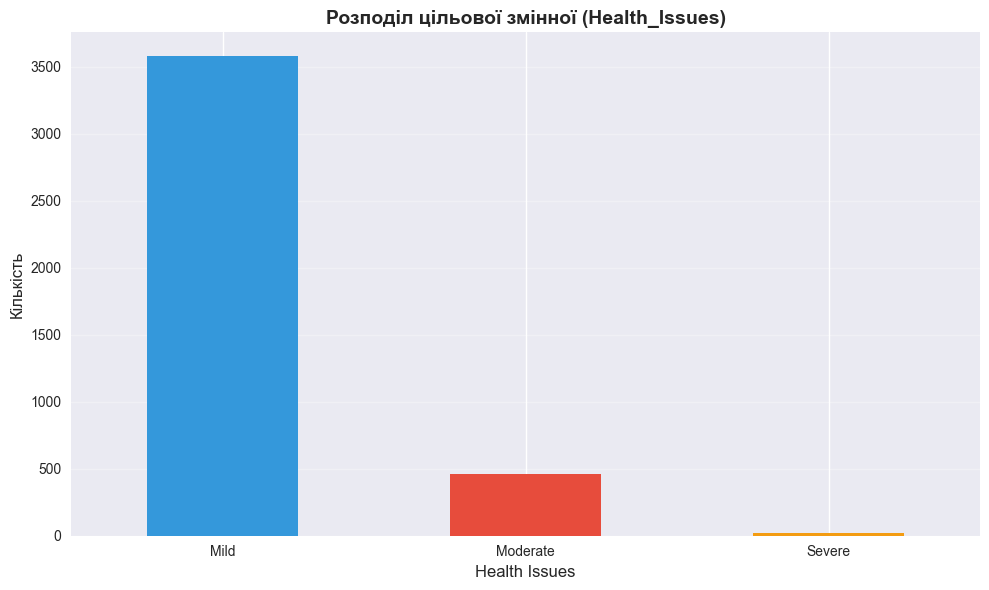

In [21]:
#Аналіз цільової змінної
print("Розподіл цільової змінної (Health_Issues):")
print(df['Health_Issues'].value_counts())
print("\nВідсотковий розподіл:")
print(df['Health_Issues'].value_counts(normalize=True) * 100)

#Візуалізація розподілу
plt.figure(figsize=(10, 6))
df['Health_Issues'].value_counts().plot(kind='bar', color=['#3498db', '#e74c3c', '#f39c12'])
plt.title('Розподіл цільової змінної (Health_Issues)', fontsize=14, fontweight='bold')
plt.xlabel('Health Issues', fontsize=12)
plt.ylabel('Кількість', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

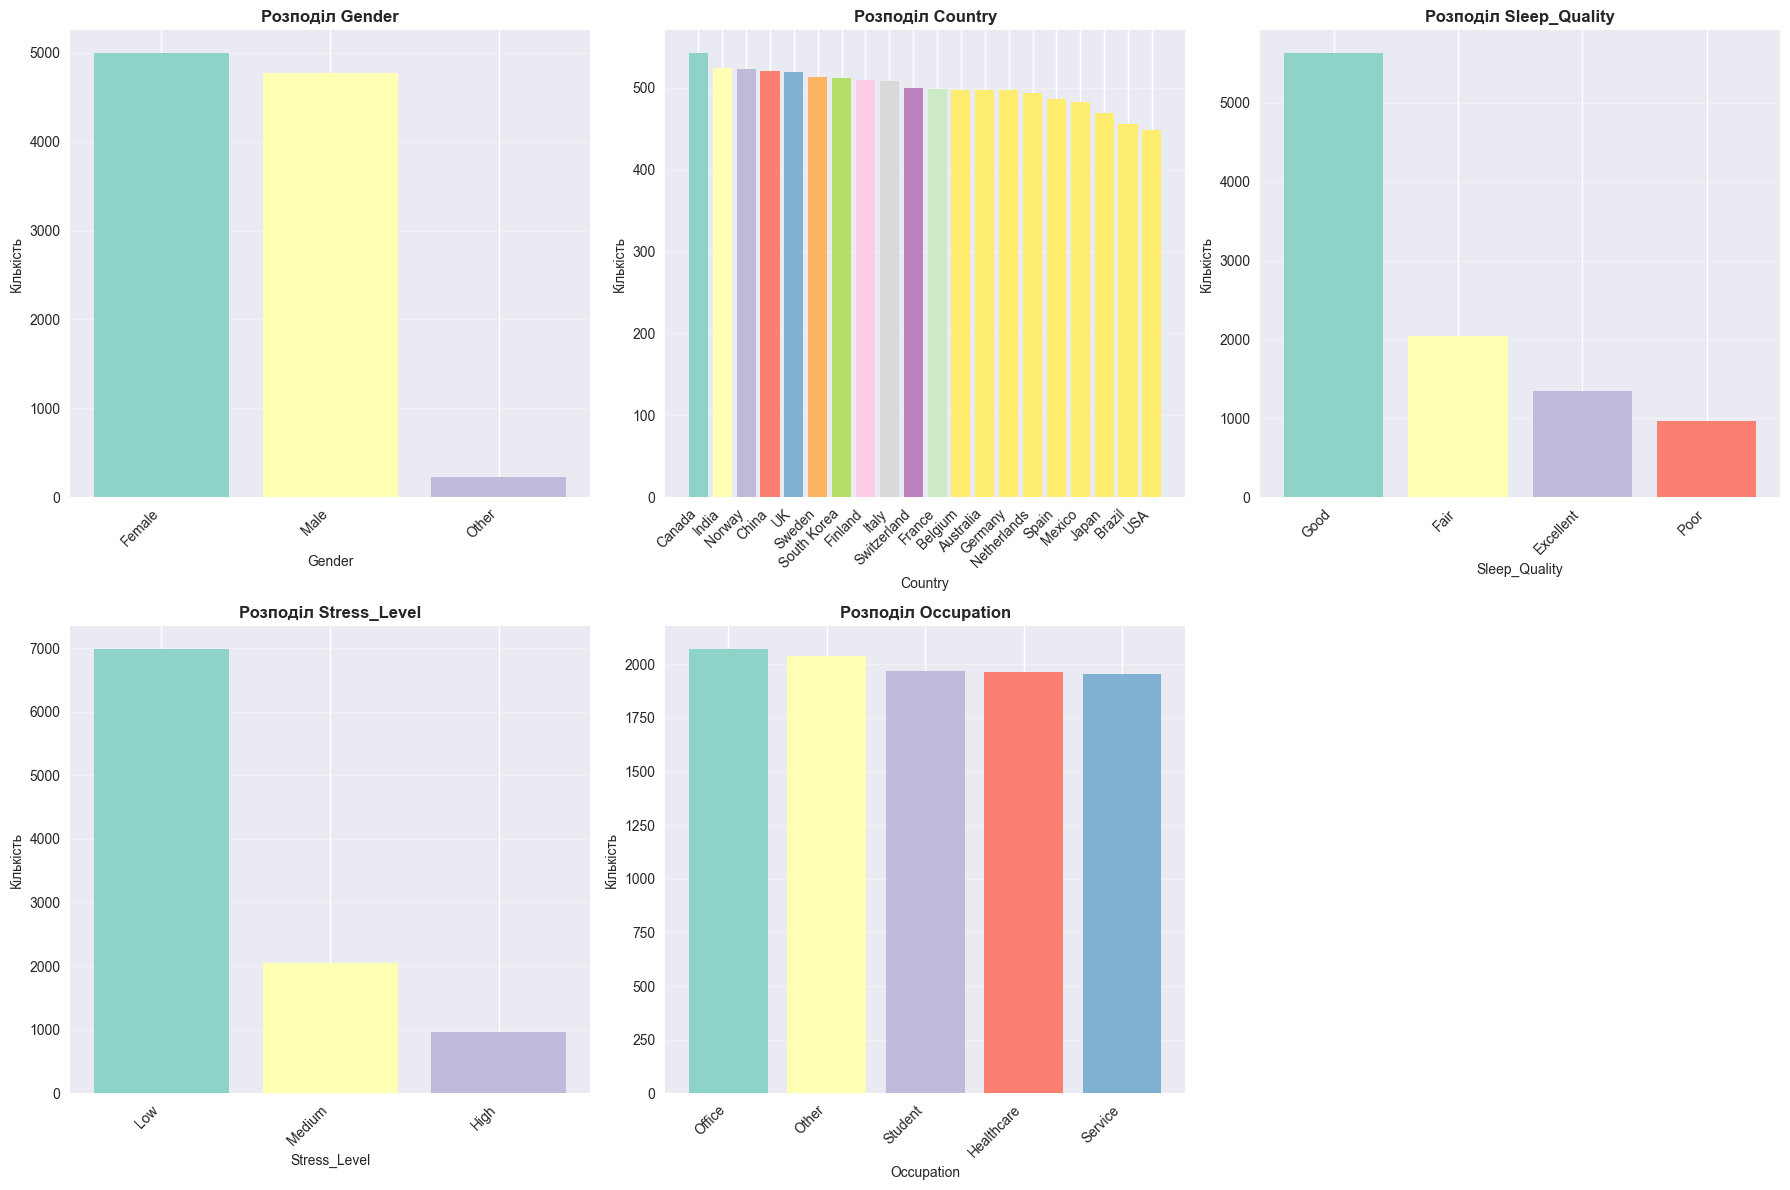

In [22]:
#Аналіз категоріальних змінних
categorical_cols = ['Gender', 'Country', 'Sleep_Quality', 'Stress_Level', 'Occupation']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):
    value_counts = df[col].value_counts()
    axes[idx].bar(range(len(value_counts)), value_counts.values, 
                  color=plt.cm.Set3(range(len(value_counts))))
    axes[idx].set_title(f'Розподіл {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Кількість', fontsize=10)
    axes[idx].set_xticks(range(len(value_counts)))
    axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right')
    axes[idx].grid(axis='y', alpha=0.3)

#Прибрати останній порожній subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

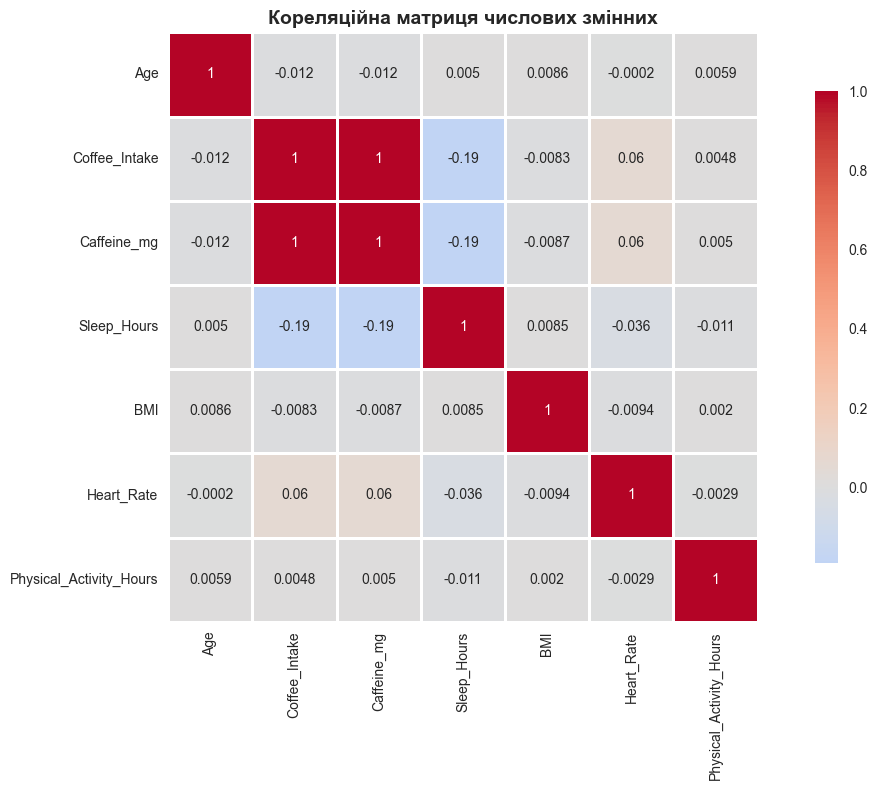

In [23]:
#Кореляційна матриця для числових змінних
numeric_cols = ['Age', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 'BMI', 
                'Heart_Rate', 'Physical_Activity_Hours']

plt.figure(figsize=(12, 8))
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Кореляційна матриця числових змінних', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [31]:
data = df.copy()

#Видалення ID
data = data.drop('ID', axis=1)

data = data.dropna(subset=['Health_Issues'])

#Кодування категоріальних змінних
label_encoders = {}
categorical_features = ['Gender', 'Country', 'Sleep_Quality', 'Stress_Level', 'Occupation']

for col in categorical_features:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le
    print(f"{col}: {len(le.classes_)} класів")

#Кодування цільової змінної
target_encoder = LabelEncoder()
data['Health_Issues_encoded'] = target_encoder.fit_transform(data['Health_Issues'])
print(f"\nHealth_Issues mapping: {dict(zip(target_encoder.classes_, range(len(target_encoder.classes_))))}")

#Розділення на ознаки та цільову змінну
X = data.drop(['Health_Issues', 'Health_Issues_encoded'], axis=1)
y = data['Health_Issues_encoded']

print(f"\nРозмір X: {X.shape}")
print(f"Розмір y: {y.shape}")
print(f"\nОзнаки: {list(X.columns)}")

Gender: 3 класів
Country: 20 класів
Sleep_Quality: 4 класів
Stress_Level: 3 класів
Occupation: 5 класів

Health_Issues mapping: {'Mild': 0, 'Moderate': 1, 'Severe': 2}

Розмір X: (4059, 14)
Розмір y: (4059,)

Ознаки: ['Age', 'Gender', 'Country', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 'Sleep_Quality', 'BMI', 'Heart_Rate', 'Stress_Level', 'Physical_Activity_Hours', 'Occupation', 'Smoking', 'Alcohol_Consumption']


In [32]:
#Розділення на навчальну та тестову вибірки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Розмір навчальної вибірки: {X_train.shape}")
print(f"Розмір тестової вибірки: {X_test.shape}")
print(f"\nРозподіл класів у навчальній вибірці:")
print(pd.Series(y_train).value_counts().sort_index())
print(f"\nРозподіл класів у тестовій вибірці:")
print(pd.Series(y_test).value_counts().sort_index())

Розмір навчальної вибірки: (3247, 14)
Розмір тестової вибірки: (812, 14)

Розподіл класів у навчальній вибірці:
Health_Issues_encoded
0    2863
1     370
2      14
Name: count, dtype: int64

Розподіл класів у тестовій вибірці:
Health_Issues_encoded
0    716
1     93
2      3
Name: count, dtype: int64


In [33]:
#Дерево рішень з критерієм Gini
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X_train, y_train)

#Прогнози
y_pred_gini = dt_gini.predict(X_test)

#Метрики
accuracy_gini = accuracy_score(y_test, y_pred_gini)
precision_gini = precision_score(y_test, y_pred_gini, average='weighted')
recall_gini = recall_score(y_test, y_pred_gini, average='weighted')
f1_gini = f1_score(y_test, y_pred_gini, average='weighted')

print("Базове дерево рішень (критерій Gini):")
print(f"Точність (Accuracy): {accuracy_gini:.4f}")
print(f"Точність (Precision): {precision_gini:.4f}")
print(f"Повнота (Recall): {recall_gini:.4f}")
print(f"F1-метрика: {f1_gini:.4f}")
print(f"\nГлибина дерева: {dt_gini.tree_.max_depth}")
print(f"Кількість листів: {dt_gini.tree_.n_leaves}")

Базове дерево рішень (критерій Gini):
Точність (Accuracy): 0.9926
Точність (Precision): 0.9926
Повнота (Recall): 0.9926
F1-метрика: 0.9925

Глибина дерева: 6
Кількість листів: 13


In [34]:
#Дерево рішень з критерієм Entropy
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_entropy.fit(X_train, y_train)

#Прогнози
y_pred_entropy = dt_entropy.predict(X_test)

#Метрики
accuracy_entropy = accuracy_score(y_test, y_pred_entropy)
precision_entropy = precision_score(y_test, y_pred_entropy, average='weighted')
recall_entropy = recall_score(y_test, y_pred_entropy, average='weighted')
f1_entropy = f1_score(y_test, y_pred_entropy, average='weighted')

print("Базове дерево рішень (критерій Entropy):")
print(f"Точність (Accuracy): {accuracy_entropy:.4f}")
print(f"Точність (Precision): {precision_entropy:.4f}")
print(f"Повнота (Recall): {recall_entropy:.4f}")
print(f"F1-метрика: {f1_entropy:.4f}")
print(f"\nГлибина дерева: {dt_entropy.tree_.max_depth}")
print(f"Кількість листів: {dt_entropy.tree_.n_leaves}")

Базове дерево рішень (критерій Entropy):
Точність (Accuracy): 0.9926
Точність (Precision): 0.9926
Повнота (Recall): 0.9926
F1-метрика: 0.9925

Глибина дерева: 6
Кількість листів: 13


In [35]:
#Порівняння критеріїв
comparison_df = pd.DataFrame({
    'Критерій': ['Gini', 'Entropy'],
    'Accuracy': [accuracy_gini, accuracy_entropy],
    'Precision': [precision_gini, precision_entropy],
    'Recall': [recall_gini, recall_entropy],
    'F1-Score': [f1_gini, f1_entropy],
    'Глибина': [dt_gini.tree_.max_depth, dt_entropy.tree_.max_depth],
    'Листів': [dt_gini.tree_.n_leaves, dt_entropy.tree_.n_leaves]
})

print("Порівняння критеріїв:")
print(comparison_df.to_string(index=False))

Порівняння критеріїв:
Критерій  Accuracy  Precision   Recall  F1-Score  Глибина  Листів
    Gini  0.992611    0.99259 0.992611   0.99254        6      13
 Entropy  0.992611    0.99259 0.992611   0.99254        6      13


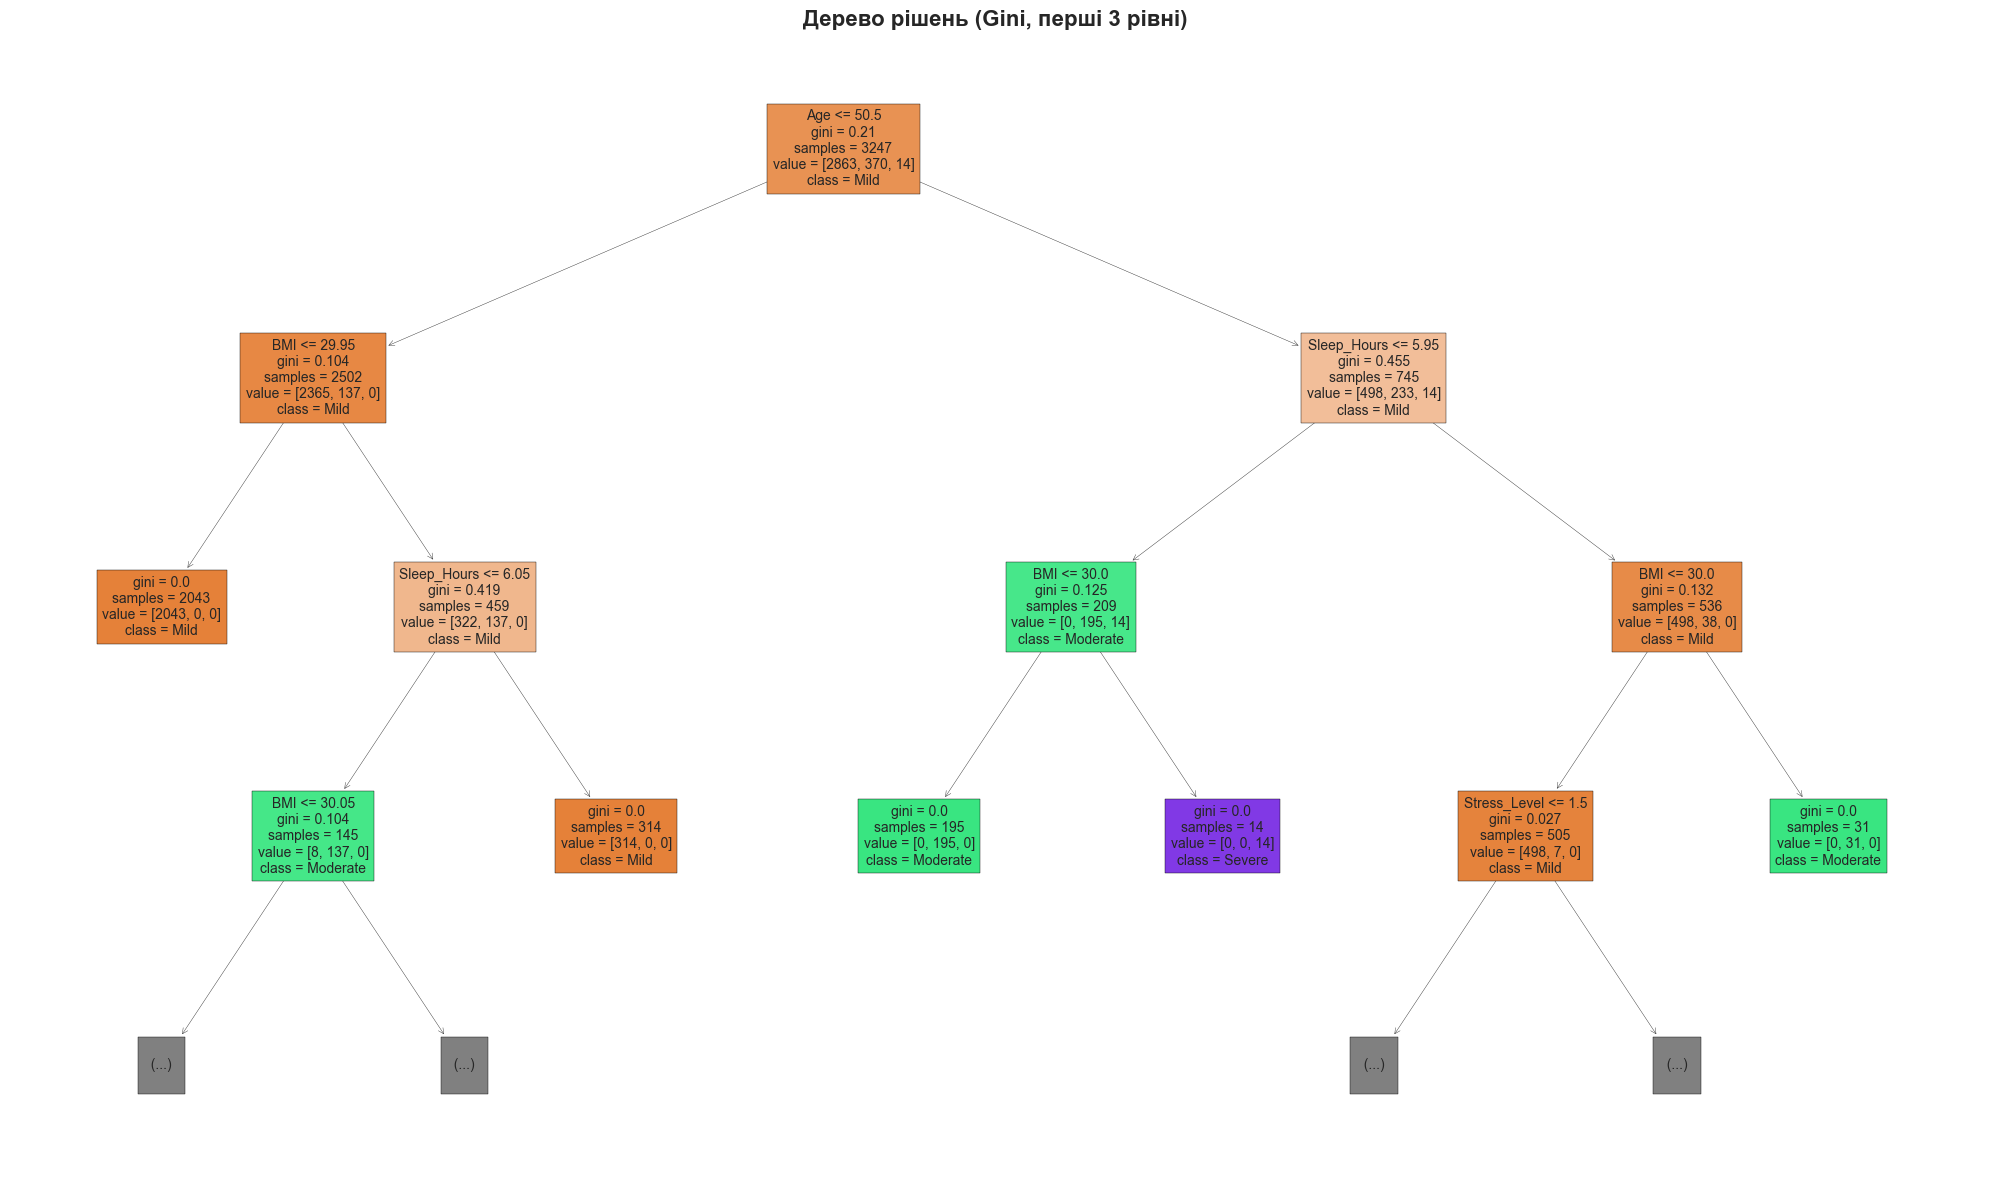

In [36]:
#Візуалізація дерева
plt.figure(figsize=(20, 12))
plot_tree(dt_gini, max_depth=3, filled=True, feature_names=X.columns, 
          class_names=target_encoder.classes_, fontsize=10)
plt.title('Дерево рішень (Gini, перші 3 рівні)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [37]:
#Текстовий вивід дерева (перші 10 рівнів)
tree_rules = export_text(dt_gini, feature_names=list(X.columns), max_depth=10)
print("Правила дерева рішень (перші 10 рівнів):")
print(tree_rules)

Правила дерева рішень (перші 10 рівнів):
|--- Age <= 50.50
|   |--- BMI <= 29.95
|   |   |--- class: 0
|   |--- BMI >  29.95
|   |   |--- Sleep_Hours <= 6.05
|   |   |   |--- BMI <= 30.05
|   |   |   |   |--- Heart_Rate <= 85.50
|   |   |   |   |   |--- Caffeine_mg <= 580.85
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- Caffeine_mg >  580.85
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- Heart_Rate >  85.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- BMI >  30.05
|   |   |   |   |--- Sleep_Hours <= 5.95
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Sleep_Hours >  5.95
|   |   |   |   |   |--- Stress_Level <= 1.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- Stress_Level >  1.50
|   |   |   |   |   |   |--- class: 1
|   |   |--- Sleep_Hours >  6.05
|   |   |   |--- class: 0
|--- Age >  50.50
|   |--- Sleep_Hours <= 5.95
|   |   |--- BMI <= 30.00
|   |   |   |--- class: 1
|   |   |--- BMI >  30.00
|   |   |   |--- class: 2
| 

In [38]:
#Важливість ознак
feature_importance = pd.DataFrame({
    'Ознака': X.columns,
    'Важливість (Gini)': dt_gini.feature_importances_,
    'Важливість (Entropy)': dt_entropy.feature_importances_
}).sort_values('Важливість (Gini)', ascending=False)

print("Важливість ознак:")
print(feature_importance.to_string(index=False))

Важливість ознак:
                 Ознака  Важливість (Gini)  Важливість (Entropy)
            Sleep_Hours           0.620559              0.481837
                    BMI           0.227105              0.333302
                    Age           0.121102              0.146769
           Stress_Level           0.024701              0.033107
             Heart_Rate           0.004083              0.002805
            Caffeine_mg           0.002450              0.002180
                 Gender           0.000000              0.000000
                Country           0.000000              0.000000
          Coffee_Intake           0.000000              0.000000
          Sleep_Quality           0.000000              0.000000
Physical_Activity_Hours           0.000000              0.000000
             Occupation           0.000000              0.000000
                Smoking           0.000000              0.000000
    Alcohol_Consumption           0.000000              0.000000


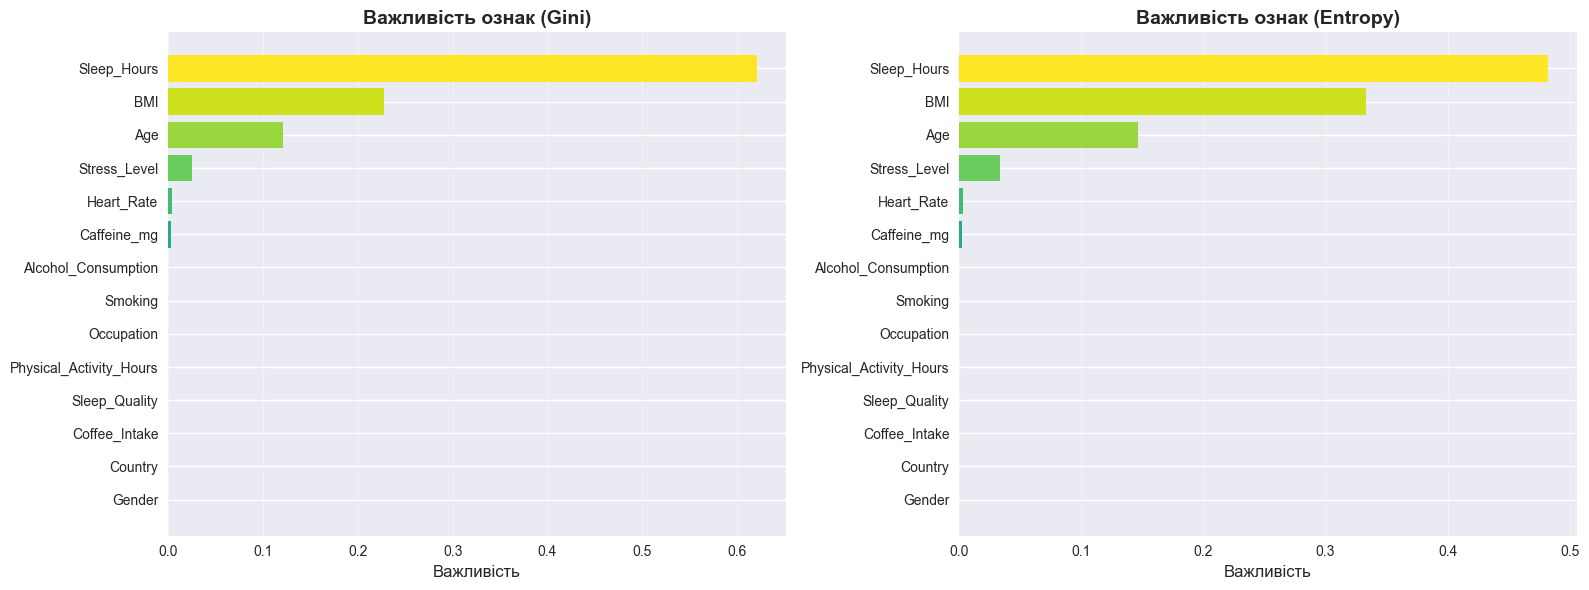

In [39]:
#Візуалізація важливості ознак
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (criterion, model) in enumerate([('Gini', dt_gini), ('Entropy', dt_entropy)]):
    importance_df = pd.DataFrame({
        'Ознака': X.columns,
        'Важливість': model.feature_importances_
    }).sort_values('Важливість', ascending=True)
    
    axes[idx].barh(importance_df['Ознака'], importance_df['Важливість'], 
                   color=plt.cm.viridis(np.linspace(0, 1, len(importance_df))))
    axes[idx].set_title(f'Важливість ознак ({criterion})', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Важливість', fontsize=12)
    axes[idx].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [42]:
# Детальний звіт про класифікацію
print("Звіт про класифікацію (Gini):")
print(classification_report(y_test, y_pred_gini, 
                          target_names=target_encoder.classes_))

print("\n" + "="*60 + "\n")

print("Звіт про класифікацію (Entropy):")
print(classification_report(y_test, y_pred_entropy, 
                          target_names=target_encoder.classes_))


Звіт про класифікацію (Gini):
              precision    recall  f1-score   support

        Mild       0.99      1.00      1.00       716
    Moderate       0.99      0.95      0.97        93
      Severe       1.00      1.00      1.00         3

    accuracy                           0.99       812
   macro avg       0.99      0.98      0.99       812
weighted avg       0.99      0.99      0.99       812



Звіт про класифікацію (Entropy):
              precision    recall  f1-score   support

        Mild       0.99      1.00      1.00       716
    Moderate       0.99      0.95      0.97        93
      Severe       1.00      1.00      1.00         3

    accuracy                           0.99       812
   macro avg       0.99      0.98      0.99       812
weighted avg       0.99      0.99      0.99       812



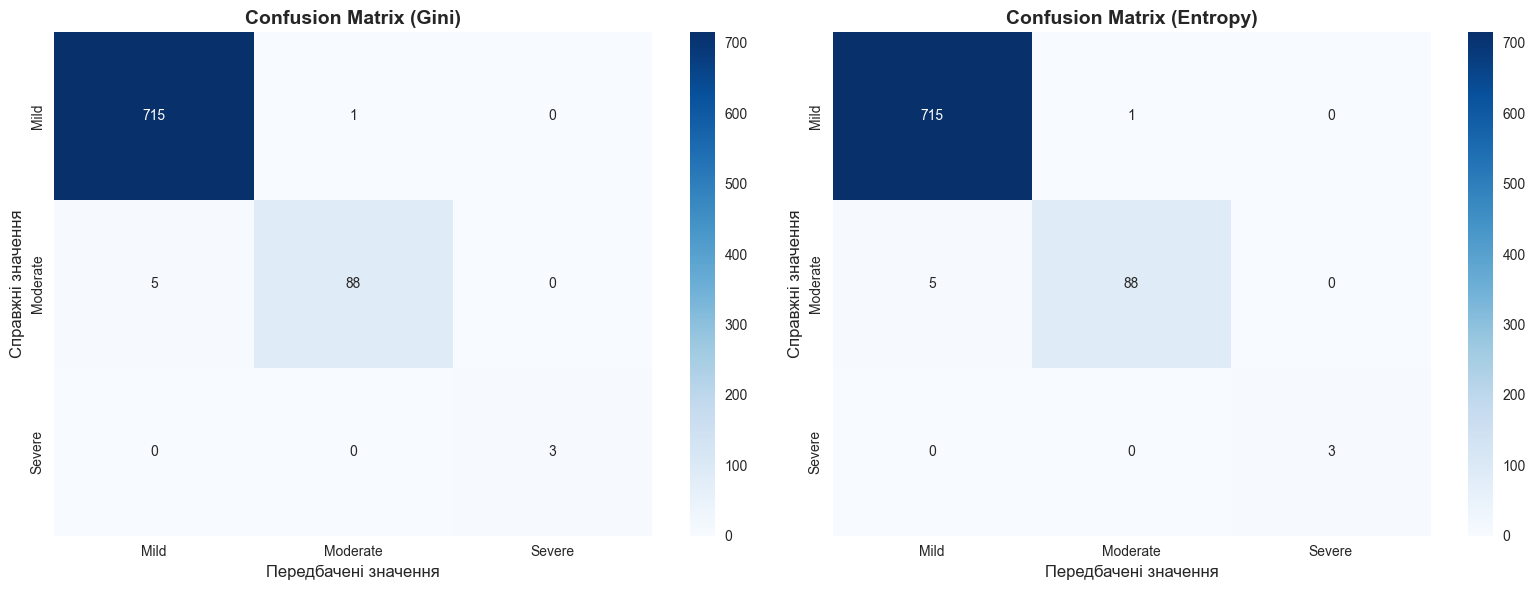

In [43]:
#Матриця конфузії
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (model, name, y_pred) in enumerate([
    (dt_gini, 'Gini', y_pred_gini),
    (dt_entropy, 'Entropy', y_pred_entropy)
]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=target_encoder.classes_,
                yticklabels=target_encoder.classes_)
    axes[idx].set_title(f'Confusion Matrix ({name})', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Справжні значення', fontsize=12)
    axes[idx].set_xlabel('Передбачені значення', fontsize=12)

plt.tight_layout()
plt.show()

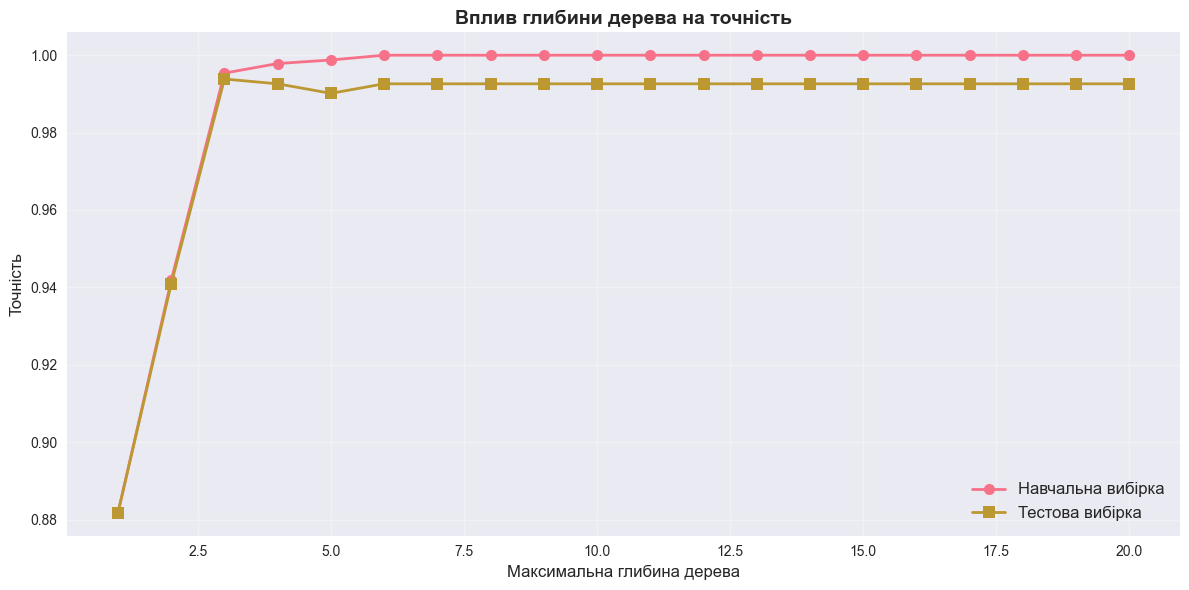

Оптимальна глибина дерева: 3
Точність на тестовій вибірці при оптимальній глибині: 0.9938


In [44]:
#Тестування різних значень max_depth
max_depths = range(1, 21)
train_scores = []
test_scores = []

for depth in max_depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42, criterion='gini')
    dt.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, dt.predict(X_train)))
    test_scores.append(accuracy_score(y_test, dt.predict(X_test)))

plt.figure(figsize=(12, 6))
plt.plot(max_depths, train_scores, 'o-', label='Навчальна вибірка', linewidth=2, markersize=8)
plt.plot(max_depths, test_scores, 's-', label='Тестова вибірка', linewidth=2, markersize=8)
plt.xlabel('Максимальна глибина дерева', fontsize=12)
plt.ylabel('Точність', fontsize=12)
plt.title('Вплив глибини дерева на точність', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#Знаходження оптимальної глибини
optimal_depth = max_depths[np.argmax(test_scores)]
print(f"Оптимальна глибина дерева: {optimal_depth}")
print(f"Точність на тестовій вибірці при оптимальній глибині: {max(test_scores):.4f}")

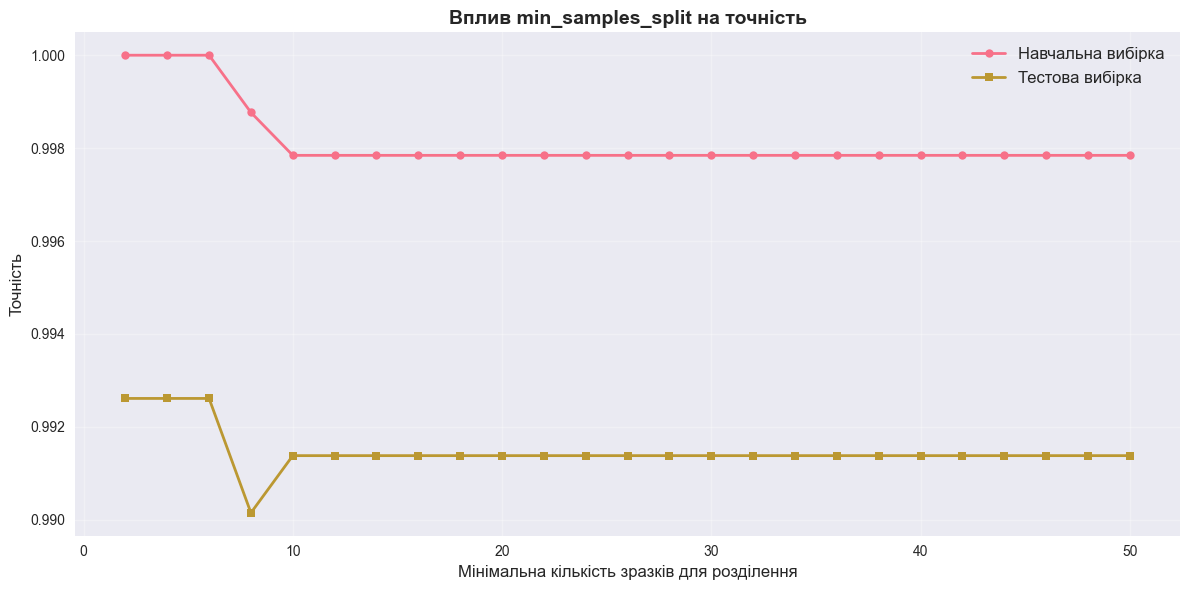

Оптимальне min_samples_split: 2
Точність на тестовій вибірці: 0.9926


In [45]:
#Тестування різних значень min_samples_split
min_splits = range(2, 51, 2)
train_scores_split = []
test_scores_split = []

for min_split in min_splits:
    dt = DecisionTreeClassifier(min_samples_split=min_split, random_state=42, criterion='gini')
    dt.fit(X_train, y_train)
    train_scores_split.append(accuracy_score(y_train, dt.predict(X_train)))
    test_scores_split.append(accuracy_score(y_test, dt.predict(X_test)))

plt.figure(figsize=(12, 6))
plt.plot(min_splits, train_scores_split, 'o-', label='Навчальна вибірка', linewidth=2, markersize=6)
plt.plot(min_splits, test_scores_split, 's-', label='Тестова вибірка', linewidth=2, markersize=6)
plt.xlabel('Мінімальна кількість зразків для розділення', fontsize=12)
plt.ylabel('Точність', fontsize=12)
plt.title('Вплив min_samples_split на точність', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#Знаходження оптимального значення
optimal_split = min_splits[np.argmax(test_scores_split)]
print(f"Оптимальне min_samples_split: {optimal_split}")
print(f"Точність на тестовій вибірці: {max(test_scores_split):.4f}")

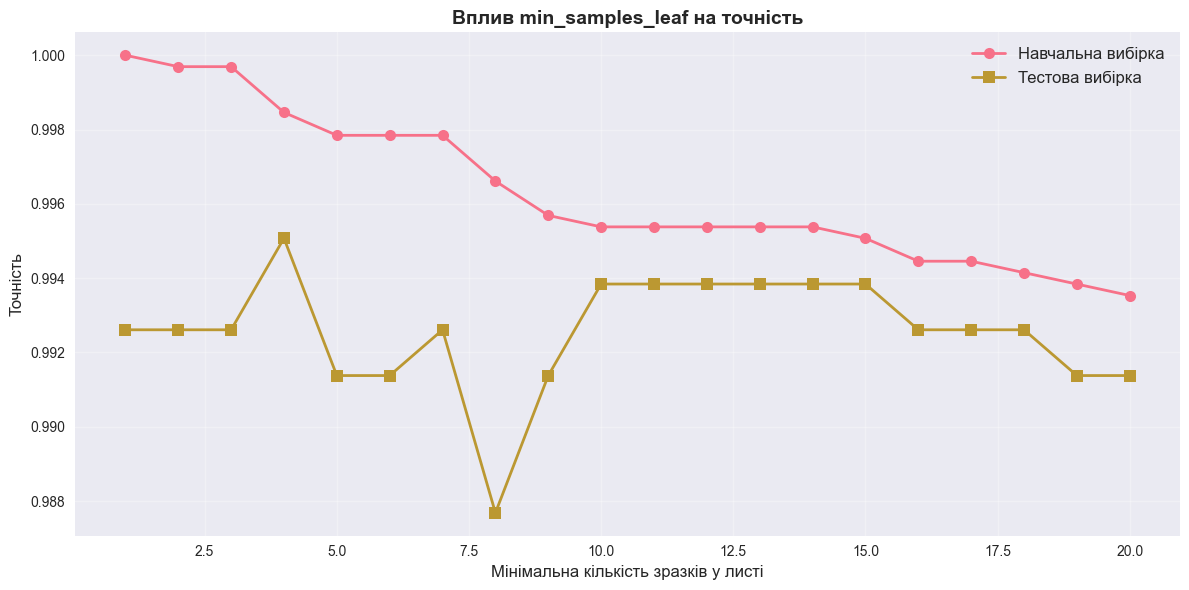

Оптимальне min_samples_leaf: 4
Точність на тестовій вибірці: 0.9951


In [46]:
#Тестування різних значень min_samples_leaf
min_leaves = range(1, 21)
train_scores_leaf = []
test_scores_leaf = []

for min_leaf in min_leaves:
    dt = DecisionTreeClassifier(min_samples_leaf=min_leaf, random_state=42, criterion='gini')
    dt.fit(X_train, y_train)
    train_scores_leaf.append(accuracy_score(y_train, dt.predict(X_train)))
    test_scores_leaf.append(accuracy_score(y_test, dt.predict(X_test)))

plt.figure(figsize=(12, 6))
plt.plot(min_leaves, train_scores_leaf, 'o-', label='Навчальна вибірка', linewidth=2, markersize=8)
plt.plot(min_leaves, test_scores_leaf, 's-', label='Тестова вибірка', linewidth=2, markersize=8)
plt.xlabel('Мінімальна кількість зразків у листі', fontsize=12)
plt.ylabel('Точність', fontsize=12)
plt.title('Вплив min_samples_leaf на точність', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#Знаходження оптимального значення
optimal_leaf = min_leaves[np.argmax(test_scores_leaf)]
print(f"Оптимальне min_samples_leaf: {optimal_leaf}")
print(f"Точність на тестовій вибірці: {max(test_scores_leaf):.4f}")

In [47]:
#Визначення параметрів для пошуку
param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}

#Створення моделі
dt_base = DecisionTreeClassifier(random_state=42)

#Grid Search з крос-валідацією
print("Початок пошуку оптимальних параметрів...")
grid_search = GridSearchCV(
    dt_base, param_grid, cv=5, scoring='accuracy', 
    n_jobs=-1, verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nНайкращі параметри: {grid_search.best_params_}")
print(f"Найкраща точність (CV): {grid_search.best_score_:.4f}")

Початок пошуку оптимальних параметрів...
Fitting 5 folds for each of 160 candidates, totalling 800 fits

Найкращі параметри: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Найкраща точність (CV): 0.9982


In [62]:
#Модель з оптимальними параметрами
dt_optimized = grid_search.best_estimator_
y_pred_optimized = dt_optimized.predict(X_test)

#Метрики
accuracy_opt = accuracy_score(y_test, y_pred_optimized)
precision_opt = precision_score(y_test, y_pred_optimized, average='weighted')
recall_opt = recall_score(y_test, y_pred_optimized, average='weighted')
f1_opt = f1_score(y_test, y_pred_optimized, average='weighted')

print("Оптимізована модель:")
print(f"Точність (Accuracy): {accuracy_opt:.4f}")
print(f"Точність (Precision): {precision_opt:.4f}")
print(f"Повнота (Recall): {recall_opt:.4f}")
print(f"F1-метрика: {f1_opt:.4f}")
print(f"\nГлибина дерева: {dt_optimized.tree_.max_depth}")
print(f"Кількість листів: {dt_optimized.tree_.n_leaves}")

Оптимізована модель:
Точність (Accuracy): 0.9926
Точність (Precision): 0.9926
Повнота (Recall): 0.9926
F1-метрика: 0.9925

Глибина дерева: 6
Кількість листів: 13


In [49]:
#Крос-валідація для різних моделей
models = {
    'Базове (Gini)': DecisionTreeClassifier(criterion='gini', random_state=42),
    'Базове (Entropy)': DecisionTreeClassifier(criterion='entropy', random_state=42),
    'Обмежена глибина (depth=10)': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Оптимізована': dt_optimized
}

cv_results = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_results[name] = cv_scores
    print(f"{name}:")
    print(f"  Середня точність: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    print(f"  Мінімум: {cv_scores.min():.4f}, Максимум: {cv_scores.max():.4f}")
    print()

Базове (Gini):
  Середня точність: 0.9982 (+/- 0.0030)
  Мінімум: 0.9954, Максимум: 1.0000

Базове (Entropy):
  Середня точність: 0.9978 (+/- 0.0031)
  Мінімум: 0.9954, Максимум: 1.0000

Обмежена глибина (depth=10):
  Середня точність: 0.9982 (+/- 0.0030)
  Мінімум: 0.9954, Максимум: 1.0000

Оптимізована:
  Середня точність: 0.9982 (+/- 0.0030)
  Мінімум: 0.9954, Максимум: 1.0000



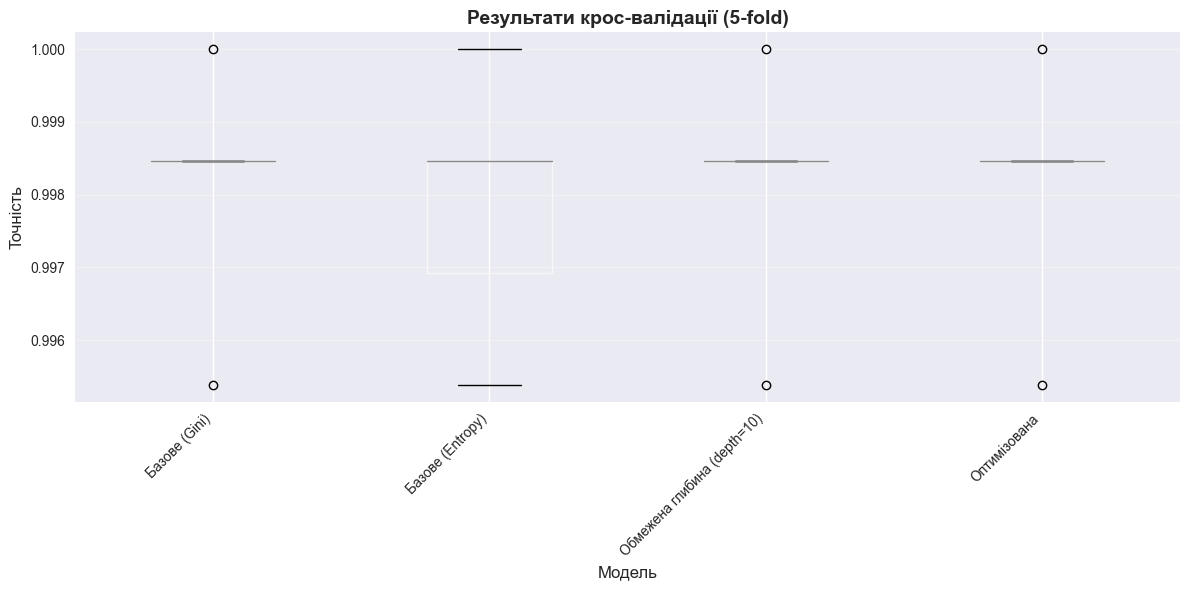

In [50]:
#Візуалізація результатів крос-валідації
plt.figure(figsize=(12, 6))
cv_df = pd.DataFrame(cv_results)
cv_df.boxplot(ax=plt.gca())
plt.title('Результати крос-валідації (5-fold)', fontsize=14, fontweight='bold')
plt.ylabel('Точність', fontsize=12)
plt.xlabel('Модель', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [51]:
#Створення моделей для порівняння
dt_shallow = DecisionTreeClassifier(max_depth=10, min_samples_split=20, min_samples_leaf=4, random_state=42)
dt_shallow.fit(X_train, y_train)
y_pred_shallow = dt_shallow.predict(X_test)

#Збірка метрик
results = []
for name, y_pred in [
    ('Базове (Gini)', y_pred_gini),
    ('Базове (Entropy)', y_pred_entropy),
    ('Обмежена глибина', y_pred_shallow),
    ('Оптимізована', y_pred_optimized)
]:
    results.append({
        'Модель': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred, average='weighted')
    })

results_df = pd.DataFrame(results)
print("Порівняння моделей:")
print(results_df.to_string(index=False))

Порівняння моделей:
          Модель  Accuracy  Precision   Recall  F1-Score
   Базове (Gini)  0.992611   0.992590 0.992611  0.992540
Базове (Entropy)  0.992611   0.992590 0.992611  0.992540
Обмежена глибина  0.991379   0.991463 0.991379  0.991232
    Оптимізована  0.992611   0.992590 0.992611  0.992540


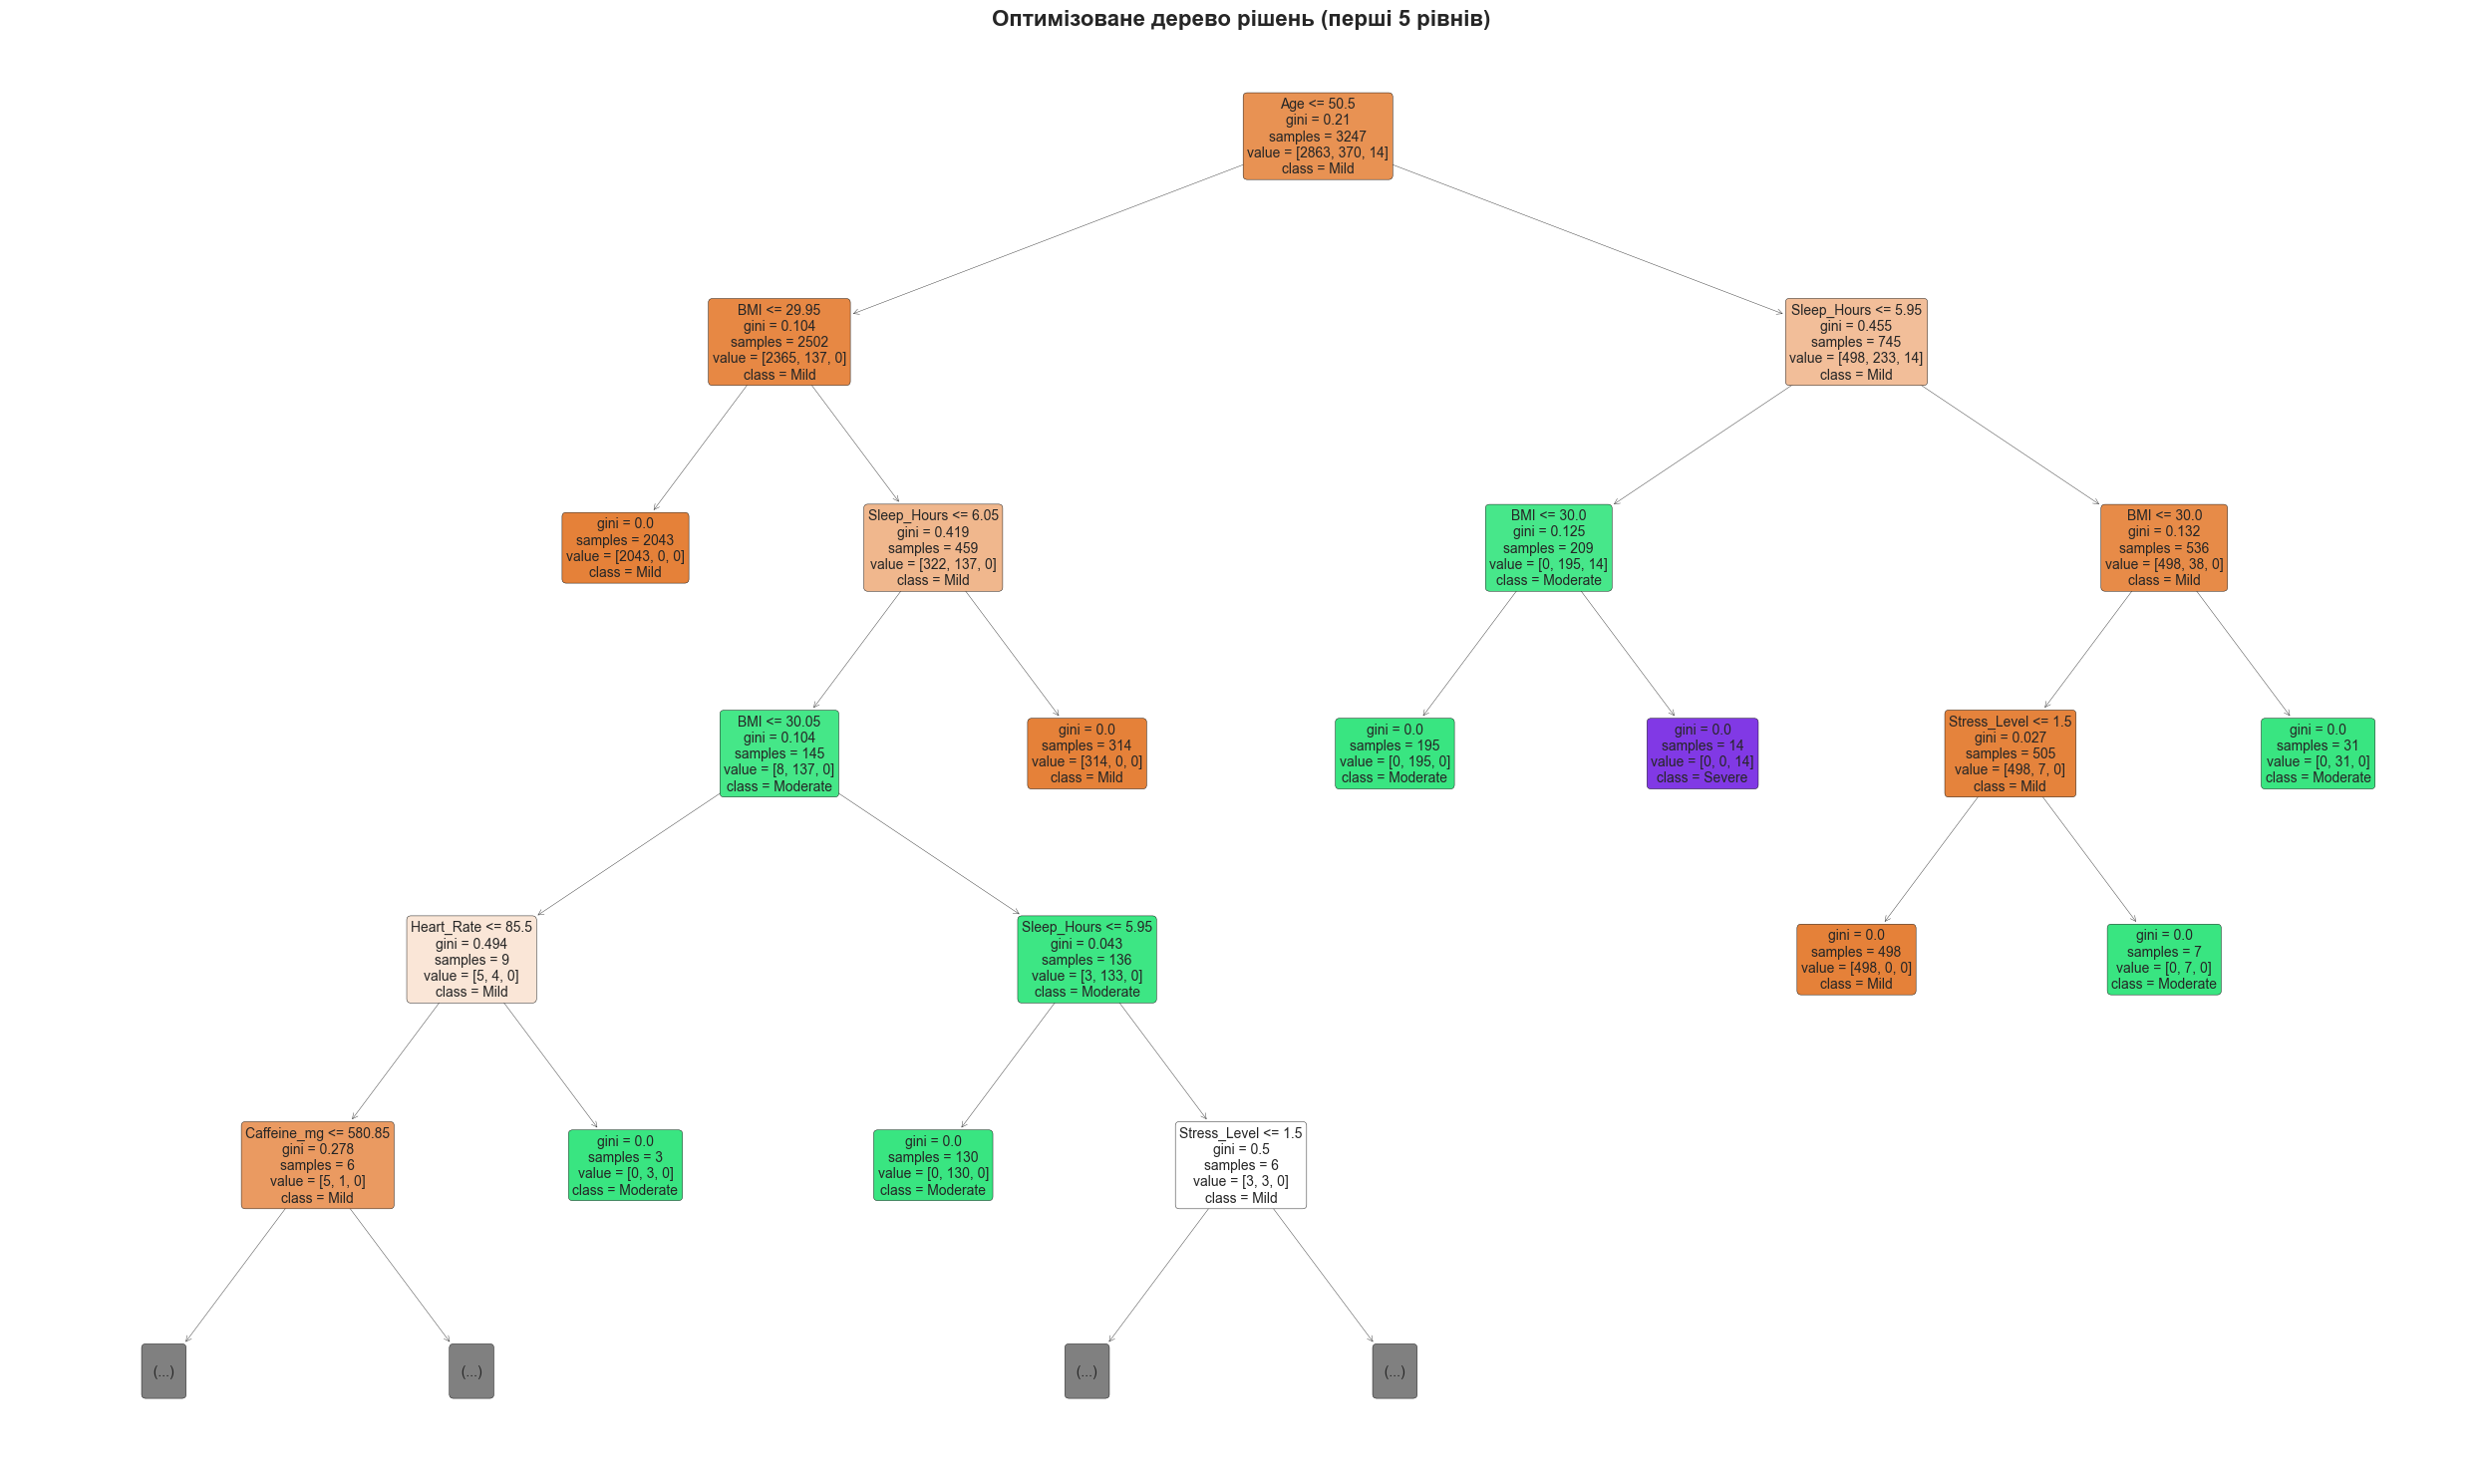

In [53]:
#Візуалізація оптимізованого дерева
plt.figure(figsize=(25, 15))
plot_tree(dt_optimized, max_depth=5, filled=True, feature_names=X.columns, 
          class_names=target_encoder.classes_, fontsize=10, rounded=True)
plt.title('Оптимізоване дерево рішень (перші 5 рівнів)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Топ-10 найважливіших ознак:
       Ознака  Важливість
  Sleep_Hours    0.620559
          BMI    0.227105
          Age    0.121102
 Stress_Level    0.024701
   Heart_Rate    0.004083
  Caffeine_mg    0.002450
       Gender    0.000000
      Country    0.000000
Coffee_Intake    0.000000
Sleep_Quality    0.000000


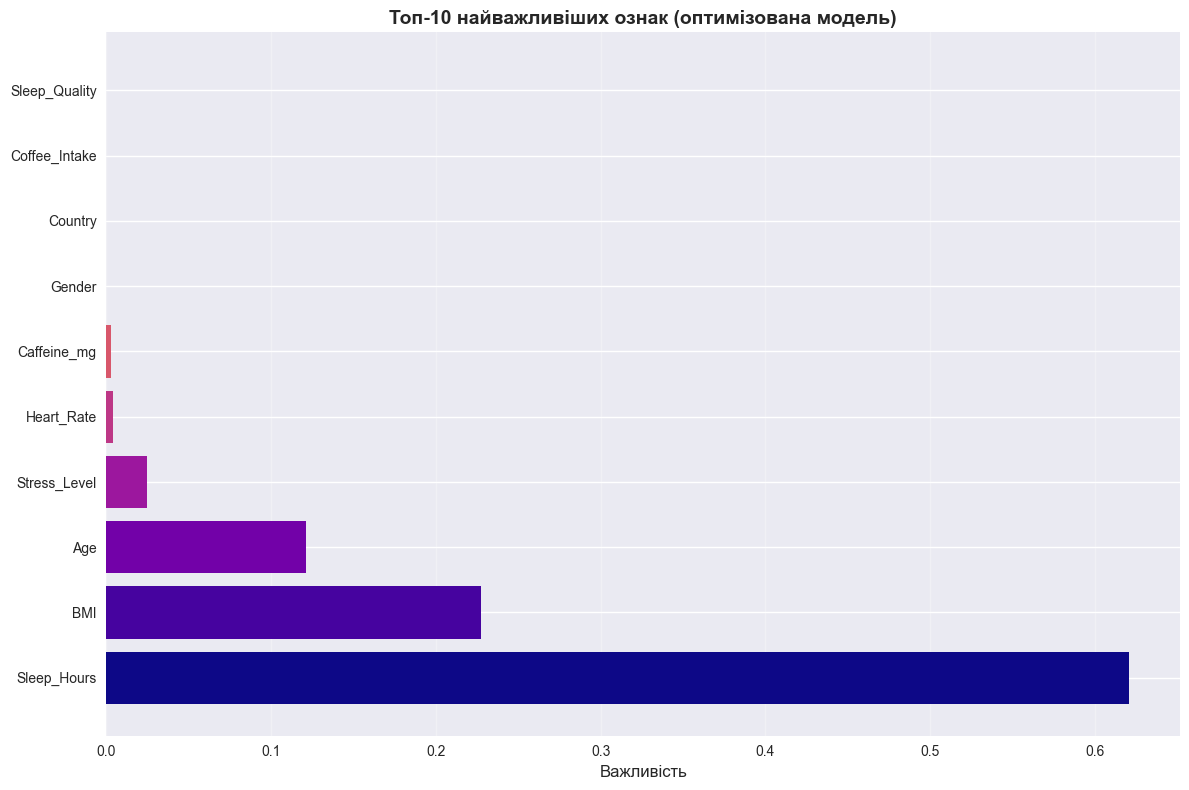

In [54]:
#Важливість ознак для оптимізованої моделі
optimized_importance = pd.DataFrame({
    'Ознака': X.columns,
    'Важливість': dt_optimized.feature_importances_
}).sort_values('Важливість', ascending=False)

print("Топ-10 найважливіших ознак:")
print(optimized_importance.head(10).to_string(index=False))

# Візуалізація
plt.figure(figsize=(12, 8))
top_features = optimized_importance.head(10)
plt.barh(top_features['Ознака'], top_features['Важливість'], 
         color=plt.cm.plasma(np.linspace(0, 1, len(top_features))))
plt.title('Топ-10 найважливіших ознак (оптимізована модель)', fontsize=14, fontweight='bold')
plt.xlabel('Важливість', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

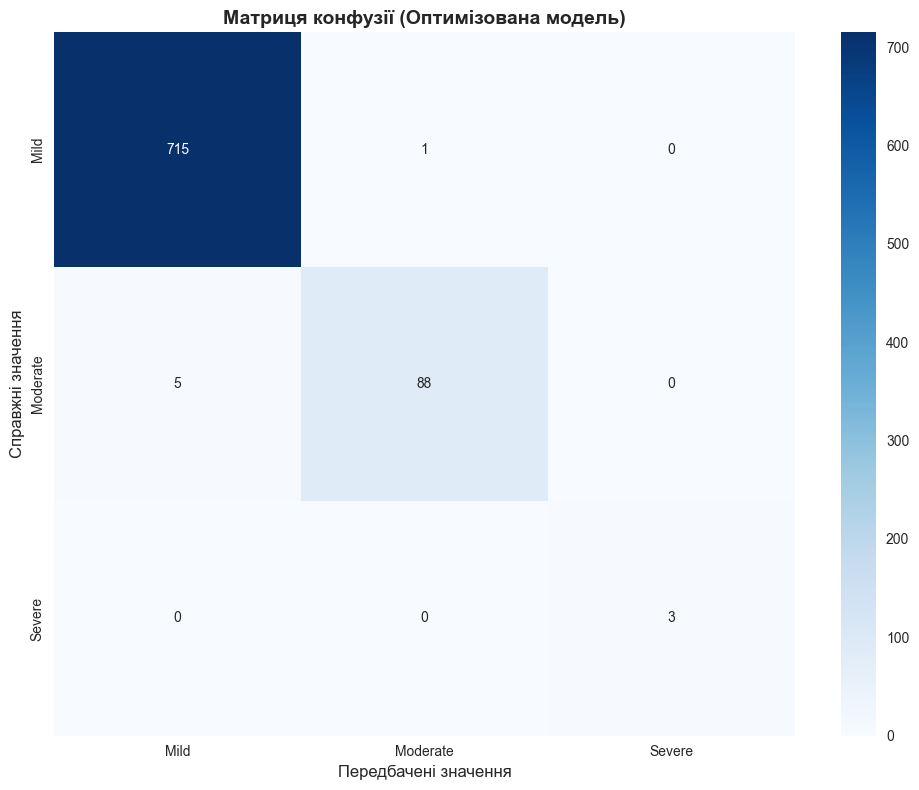

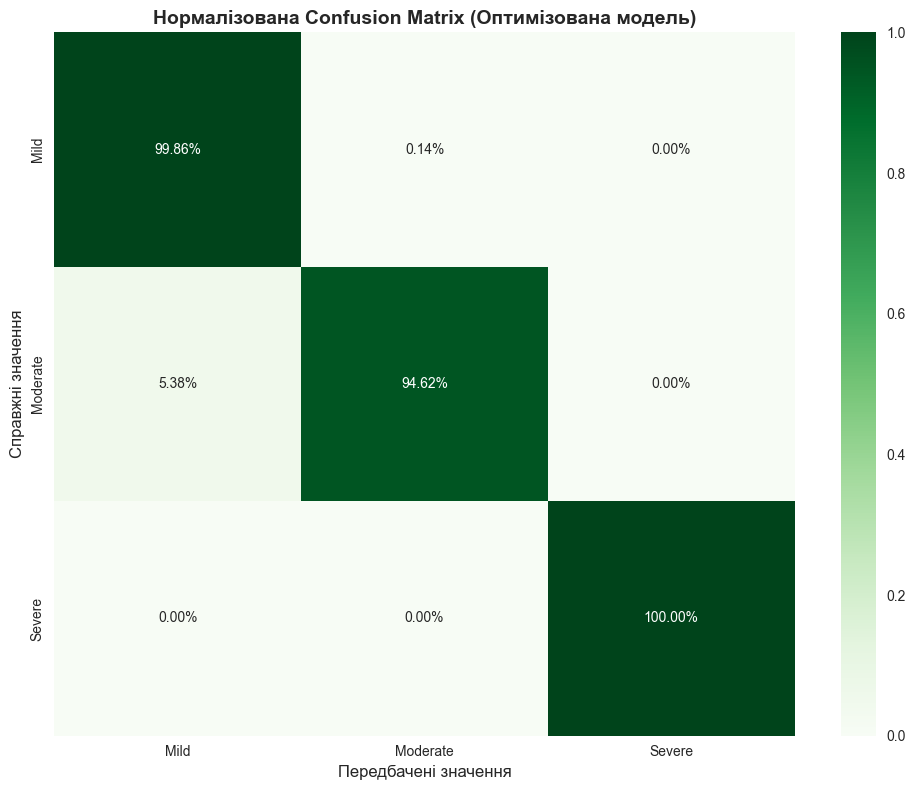

In [55]:
#Confusion Matrix для оптимізованої моделі
cm_optimized = confusion_matrix(y_test, y_pred_optimized)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)
plt.title('Матриця конфузії (Оптимізована модель)', fontsize=14, fontweight='bold')
plt.ylabel('Справжні значення', fontsize=12)
plt.xlabel('Передбачені значення', fontsize=12)
plt.tight_layout()
plt.show()

#Нормалізована матриця конфузії
cm_normalized = cm_optimized.astype('float') / cm_optimized.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)
plt.title('Нормалізована Confusion Matrix (Оптимізована модель)', fontsize=14, fontweight='bold')
plt.ylabel('Справжні значення', fontsize=12)
plt.xlabel('Передбачені значення', fontsize=12)
plt.tight_layout()
plt.show()

In [57]:
#Звіт для оптимізованої моделі
print(classification_report(y_test, y_pred_optimized, 
                          target_names=target_encoder.classes_, digits=4))

              precision    recall  f1-score   support

        Mild     0.9931    0.9986    0.9958       716
    Moderate     0.9888    0.9462    0.9670        93
      Severe     1.0000    1.0000    1.0000         3

    accuracy                         0.9926       812
   macro avg     0.9939    0.9816    0.9876       812
weighted avg     0.9926    0.9926    0.9925       812



In [58]:
#Приклади прогнозування на тестовій вибірці
sample_indices = np.random.choice(X_test.index, size=10, replace=False)
sample_data = X_test.loc[sample_indices]
sample_true = y_test.loc[sample_indices]
sample_pred = dt_optimized.predict(sample_data)

results_sample = pd.DataFrame({
    'Індекс': sample_indices,
    'Справжнє значення': [target_encoder.classes_[i] for i in sample_true],
    'Передбачене значення': [target_encoder.classes_[i] for i in sample_pred],
    'Правильно': sample_true == sample_pred
})

print("Приклади прогнозування:")
print(results_sample.to_string(index=False))
print(f"\nТочність на прикладах: {(sample_true == sample_pred).mean():.2%}")

Приклади прогнозування:
 Індекс Справжнє значення Передбачене значення  Правильно
   3222              Mild                 Mild       True
   7872              Mild                 Mild       True
   9456              Mild                 Mild       True
     55              Mild                 Mild       True
   8628              Mild                 Mild       True
   4647              Mild                 Mild       True
   4699              Mild                 Mild       True
   7935              Mild                 Mild       True
   1474              Mild                 Mild       True
   4930              Mild                 Mild       True

Точність на прикладах: 100.00%


In [60]:
#Висновок: 

#Найкраща точність досягнута з оптимізованою моделлю: 0.9926, 
#Глибина оптимізованого дерева: 6
#Кількість листів: 13

#Найважливішими параметрами виявилися: 'Sleep_Hours', 'BMI', 'Age', 'Stress_Level' та 'Heart_Rate'

#Результати між моделями Gini та Entropy майже не відрізняються